# Project 3: Classification__

### __Objective__
In this lab, you will apply supervised learning (classification) models to predict one of the following
1. **Loan Approval Outcomes** : The dataset includes demographic, financial, and credit history features of loan applicants.
2. **Airline Passenger Satisfaction** : Customer satisfaction scores from 120,000+ airline passengers, including additional information about each passenger, their flight, and type of travel, as well as ther evaluation of different factors like cleanliness, comfort, service, and overall experience.
3. **Hotel Booking Cancellations** : booking information for a city hotel and a resort hotel, and includes information such as when the booking was made, length of stay, the number of adults, children, and/or babies, and the number of available parking spaces, among other things

### __Requirements__
Your task is to explore the data, clean and preprocess it appropriately, and build predictive models. Specifically, you must:
1. **Perform EDA**: Explore distributions, identify missing values, and check for class imbalance in the target variable.
2. **Preprocess the Data**: Handle categorical encodings, impute missing values, and scale your features. *Hint: Make sure to perform your train-test split BEFORE scaling to prevent data leakage!*
3. **Train Classification Models**: train **two** classification models (**Logistic Regression** and **KNN**).
5. **Evaluate & Compare**: Evaluate models using accuracy, precision, recall, F1-score, and confusion matrices. 

### __Deliverables__
You are expected to document your workflow using Markdown cells. Do not just write code; explain your **rationale**. Include insights from your EDA, justify your preprocessing decisions, and conclude with a comparative analysis discussing which of the three models performed best and why.

---

## __Data Dictionary__

___Copy you assigned dataset's dictionary from the guidleines___

---

## Setup and Data Loading
Import your libraries and load the dataset.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add your sklearn imports here...


In [123]:
# Load the dataset
df = pd.read_csv('./data/airline_passenger_satisfaction.csv')
df.head()


,Unnamed: 0,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,0,1,male,48,First-time,business,Business,821 miles,2 minutes,5.0 minutes,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,1,2,FEMALE,35,returning,Business,Business,821 miles,26 minutes,39.0 minutes,...,5,4,5,5,3,5,2,5,5,Satisfied
2,2,3,Male,41,Returning,Business,Business,853 miles,0 minutes,0.0 minutes,...,3,5,3,5,5,3,4,3,3,Satisfied
3,3,4,Male,50,Returning,business,Business,1905 miles,0 minutes,0.0 minutes,...,5,5,5,4,4,5,2,5,5,Satisfied
4,4,5,Female,49,returning,business,Business,3470 miles,0 minutes,1.0 minutes,...,3,4,4,5,4,3,3,3,3,Satisfied


## Part 1: Exploratory Data Analysis (EDA)
* What insights did you gain from your EDA? Are there missing values? Outliers? Is the target variable balanced or imbalanced? Use visualizations to support your findings.

In [124]:
df.dtypes


Unnamed: 0                                 int64
ID                                         int64
Gender                                    object
Age                                        int64
Customer Type                             object
Type of Travel                            object
Class                                     object
Flight Distance                           object
Departure Delay                           object
Arrival Delay                             object
Departure and Arrival Time Convenience     int64
Ease of Online Booking                     int64
Check-in Service                           int64
Online Boarding                            int64
Gate Location                              int64
On-board Service                           int64
Seat Comfort                               int64
Leg Room Service                           int64
Cleanliness                                int64
Food and Drink                             int64
In-flight Service   

In [125]:
df.shape

(136374, 25)

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136374 entries, 0 to 136373
Data columns (total 25 columns):
 #   Column                                  Non-Null Count   Dtype 
---  ------                                  --------------   ----- 
 0   Unnamed: 0                              136374 non-null  int64 
 1   ID                                      136374 non-null  int64 
 2   Gender                                  136374 non-null  object
 3   Age                                     136374 non-null  int64 
 4   Customer Type                           136374 non-null  object
 5   Type of Travel                          136374 non-null  object
 6   Class                                   136374 non-null  object
 7   Flight Distance                         136374 non-null  object
 8   Departure Delay                         136374 non-null  object
 9   Arrival Delay                           136374 non-null  object
 10  Departure and Arrival Time Convenience  136374 non-null 

In [127]:
df.isnull().sum()

Unnamed: 0                                0
ID                                        0
Gender                                    0
Age                                       0
Customer Type                             0
Type of Travel                            0
Class                                     0
Flight Distance                           0
Departure Delay                           0
Arrival Delay                             0
Departure and Arrival Time Convenience    0
Ease of Online Booking                    0
Check-in Service                          0
Online Boarding                           0
Gate Location                             0
On-board Service                          0
Seat Comfort                              0
Leg Room Service                          0
Cleanliness                               0
Food and Drink                            0
In-flight Service                         0
In-flight Wifi Service                    0
In-flight Entertainment         

In [128]:
df['Satisfaction'].value_counts()

Satisfaction
Neutral or Dissatisfied    77165
Satisfied                  59209
Name: count, dtype: int64

In [129]:
df['Satisfaction'].value_counts(normalize=True)

Satisfaction
Neutral or Dissatisfied    0.565834
Satisfied                  0.434166
Name: proportion, dtype: float64

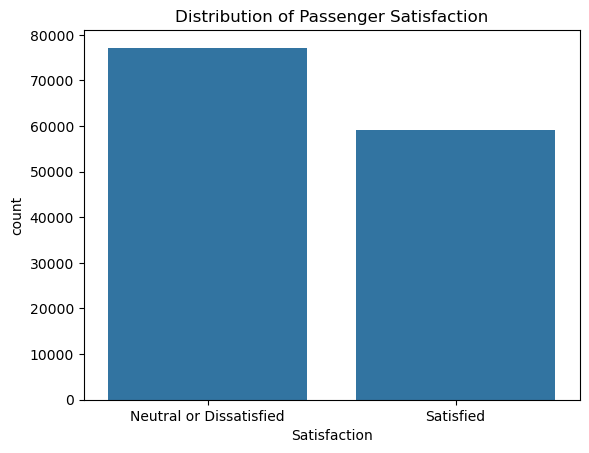

In [130]:
sns.countplot(data=df, x='Satisfaction')
plt.title('Distribution of Passenger Satisfaction')
plt.show()

In [131]:
df.describe()

,Unnamed: 0,ID,Age,Departure and Arrival Time Convenience,Ease of Online Booking,Check-in Service,Online Boarding,Gate Location,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling
count,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.00000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000,136374.000000
mean,68186.500000,64949.839676,39.415336,3.058919,2.756889,3.305733,3.251265,2.97762,3.382221,3.441052,3.351878,3.287049,3.204914,3.641779,2.728335,3.358639,3.632914
std,39367.927143,37493.148128,15.127551,1.526334,1.401928,1.265989,1.351787,1.27812,1.287022,1.319704,1.315613,1.313565,1.329990,1.176273,1.329397,1.333706,1.179430
min,0.000000,1.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,34093.250000,32495.250000,27.000000,2.000000,2.000000,3.000000,2.000000,2.00000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,2.000000,3.000000
50%,68186.500000,64945.500000,40.000000,3.000000,3.000000,3.000000,3.000000,3.00000,4.000000,4.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,4.000000
75%,102279.750000,97404.750000,51.000000,4.000000,4.000000,4.000000,4.000000,4.00000,4.000000,5.000000,4.000000,4.000000,4.000000,5.000000,4.000000,4.000000,5.000000
max,136373.000000,129880.000000,85.000000,5.000000,5.000000,5.000000,5.000000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


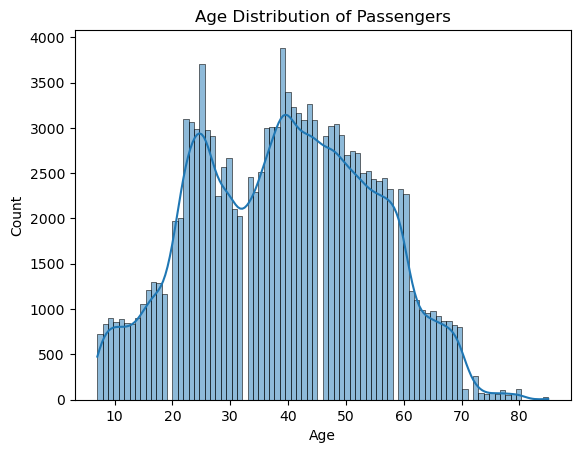

In [132]:
sns.histplot(data=df, x='Age', kde=True)
plt.title('Age Distribution of Passengers')
plt.show()

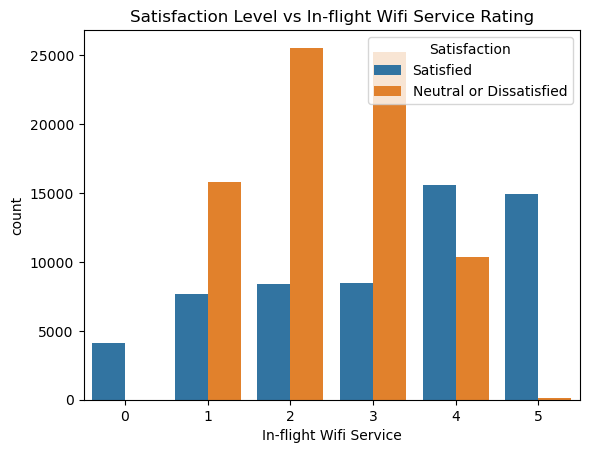

In [133]:
sns.countplot(data=df, x='In-flight Wifi Service', hue='Satisfaction')
plt.title('Satisfaction Level vs In-flight Wifi Service Rating')
plt.show()

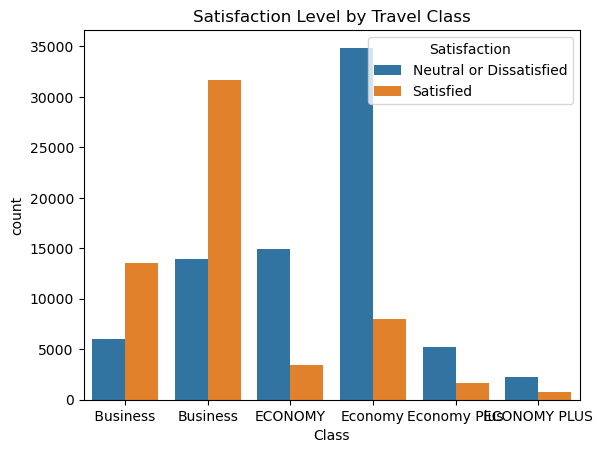

In [134]:
sns.countplot(data=df, x='Class', hue='Satisfaction')
plt.title('Satisfaction Level by Travel Class')
plt.show()

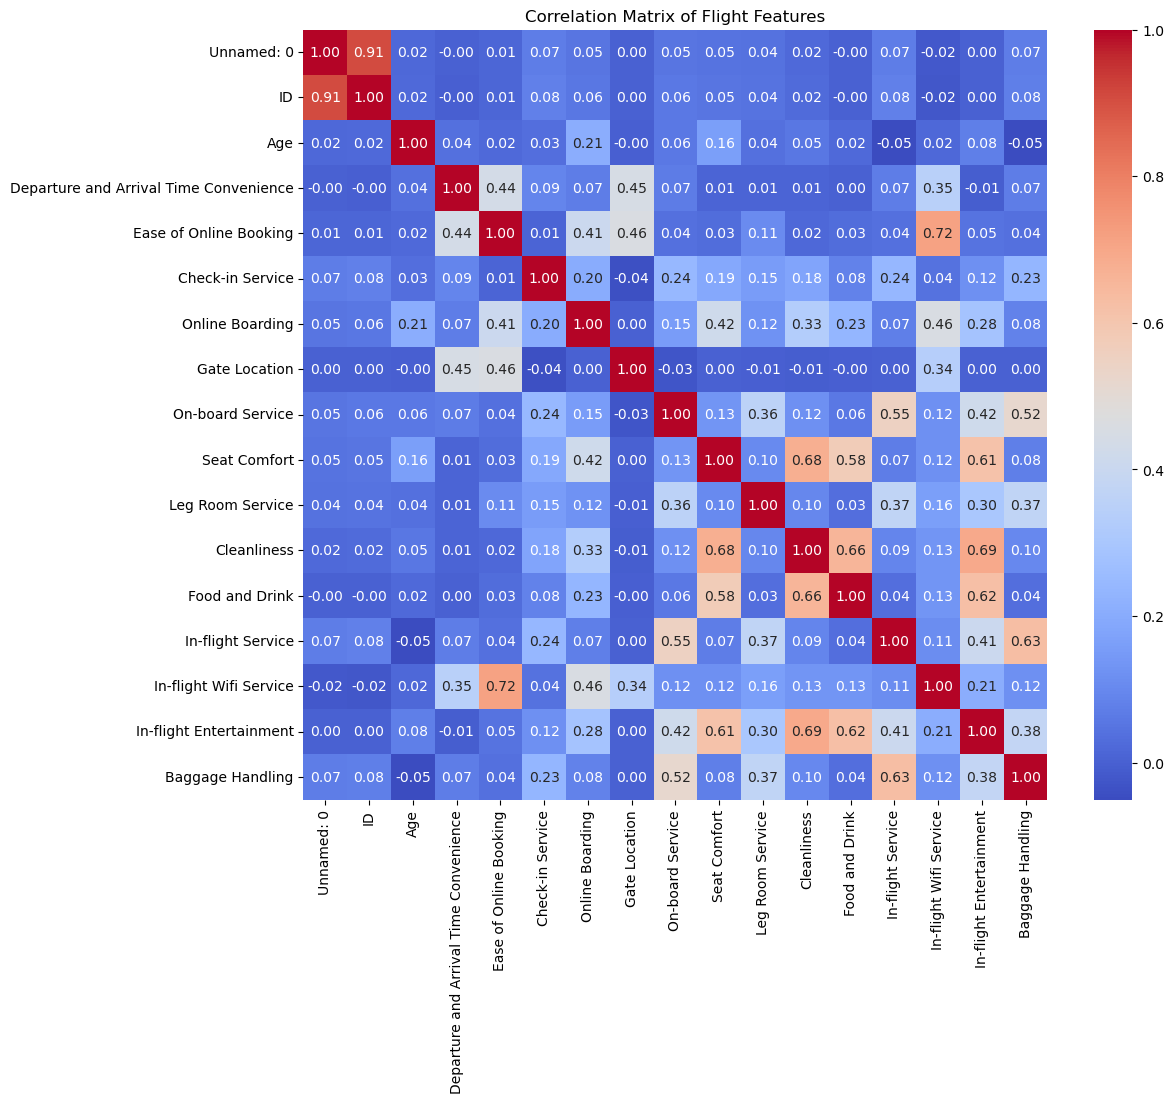

In [135]:
numerical_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Flight Features')
plt.show()

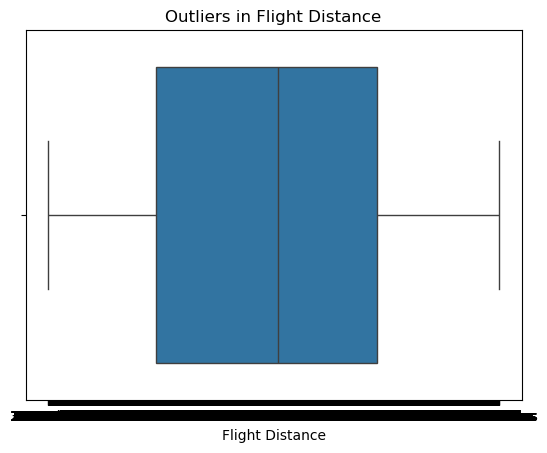

In [136]:
sns.boxplot(data=df, x='Flight Distance')
plt.title('Outliers in Flight Distance')
plt.show()

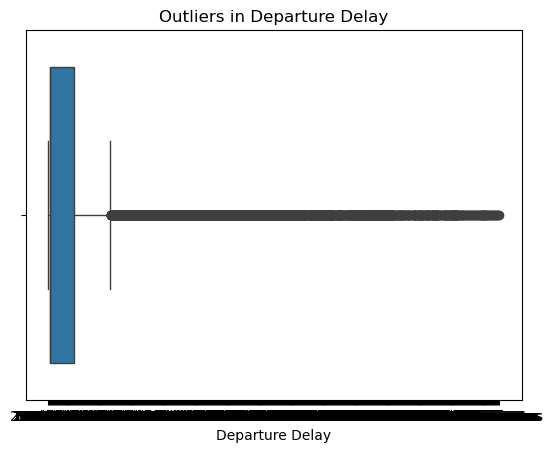

In [137]:
sns.boxplot(data=df, x='Departure Delay')
plt.title('Outliers in Departure Delay')
plt.show()

In [138]:
print(df['Gender'].unique())
print(df['Customer Type'].unique())
print(df['Class'].unique())

['male' 'FEMALE' 'Male' 'Female']
[' First-time ' 'returning' 'Returning' 'First-time']
[' Business ' 'Business' 'ECONOMY' 'Economy' 'Economy Plus' 'ECONOMY PLUS']


In [139]:
df['In-flight Wifi Service'].value_counts()

In-flight Wifi Service
2    33964
3    33770
4    25991
1    23462
5    15082
0     4105
Name: count, dtype: int64

## Part 2: Data Preprocessing
* Explain your strategy for handling categorical variables (e.g., One-Hot Encoding vs Label Encoding) and missing data.  
**Crucial:** Remember to split your data into training and testing sets BEFORE applying scaling to prevent data leakage.

In [140]:
# Your preprocessing, train_test_split, and scaling code here
# Note: you are not required to answer in this single cell, create more cells if needed
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [141]:
df['flight_distance'] = df['flight_distance'].str.replace(' miles','').astype(int)
df['departure_delay'] = df['departure_delay'].str.replace(' minutes','').astype(int)
df['arrival_delay'] = df['arrival_delay'].str.replace(' minutes','').astype(float)

In [142]:
df = df.drop(columns=['unnamed:_0'])

In [143]:
df.head()

,id,gender,age,customer_type,type_of_travel,class,flight_distance,departure_delay,arrival_delay,departure_and_arrival_time_convenience,...,on-board_service,seat_comfort,leg_room_service,cleanliness,food_and_drink,in-flight_service,in-flight_wifi_service,in-flight_entertainment,baggage_handling,satisfaction
0,1,male,48,First-time,business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,FEMALE,35,returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,returning,business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [146]:
df['gender'] = df['gender'].str.lower().str.strip()
df['customer_type'] = df['customer_type'].str.lower().str.strip()
df['type_of_travel'] = df['type_of_travel'].str.lower().str.strip()  
df['class'] = df['class'].str.lower().str.strip()

gender_mapping = {'male': 'Male', 'female': 'Female'}
customer_mapping = {'first-time': 'First-time', 'returning': 'Returning'}
travel_mapping = {'business': 'Business', 'personal': 'Personal'} 
class_mapping = {'business': 'Business', 'economy': 'Economy', 'economy plus': 'Economy Plus'}

df['gender'] = df['gender'].replace(gender_mapping)
df['customer_type'] = df['customer_type'].replace(customer_mapping)
df['type_of_travel'] = df['type_of_travel'].replace(travel_mapping)
df['class'] = df['class'].replace(class_mapping)

In [147]:
print("Gender unique values:", df['gender'].unique())
print("Customer type unique values:", df['customer_type'].unique())
print("Class unique values:", df['class'].unique())
print("type of travel unique values:", df['type_of_travel'].unique())


Gender unique values: ['Male' 'Female']
Customer type unique values: ['First-time' 'Returning']
Class unique values: ['Business' 'Economy' 'Economy Plus']
type of travel unique values: ['Business' 'Personal']


In [148]:
df.head()

,id,gender,age,customer_type,type_of_travel,class,flight_distance,departure_delay,arrival_delay,departure_and_arrival_time_convenience,...,on-board_service,seat_comfort,leg_room_service,cleanliness,food_and_drink,in-flight_service,in-flight_wifi_service,in-flight_entertainment,baggage_handling,satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [149]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136374 entries, 0 to 136373
Data columns (total 24 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   id                                      136374 non-null  int64  
 1   gender                                  136374 non-null  object 
 2   age                                     136374 non-null  int64  
 3   customer_type                           136374 non-null  object 
 4   type_of_travel                          136374 non-null  object 
 5   class                                   136374 non-null  object 
 6   flight_distance                         136374 non-null  int64  
 7   departure_delay                         136374 non-null  int64  
 8   arrival_delay                           135959 non-null  float64
 9   departure_and_arrival_time_convenience  136374 non-null  int64  
 10  ease_of_online_booking                  1363

In [150]:
df['arrival_delay'].isna().sum()

np.int64(415)

In [151]:
df['arrival_delay'] = df['arrival_delay'].fillna(df['departure_delay'])

In [152]:
df['arrival_delay'].isna().sum()

np.int64(0)

In [153]:
df = df.drop(columns=['id'])
df.head()

,gender,age,customer_type,type_of_travel,class,flight_distance,departure_delay,arrival_delay,departure_and_arrival_time_convenience,ease_of_online_booking,...,on-board_service,seat_comfort,leg_room_service,cleanliness,food_and_drink,in-flight_service,in-flight_wifi_service,in-flight_entertainment,baggage_handling,satisfaction
0,Male,48,First-time,Business,Business,821,2,5.0,3,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,Female,35,Returning,Business,Business,821,26,39.0,2,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,Male,41,Returning,Business,Business,853,0,0.0,4,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,Male,50,Returning,Business,Business,1905,0,0.0,2,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,Female,49,Returning,Business,Business,3470,0,1.0,3,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [154]:
if 'satisfaction' in df.columns:
    df['satisfaction'] = (df['satisfaction'] == 'Satisfied')*1

categorical_cols = ['gender', 'customer_type', 'type_of_travel', 'class']
categorical_cols = [col for col in categorical_cols if col in df.columns]

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

In [155]:
df.head()

,age,flight_distance,departure_delay,arrival_delay,departure_and_arrival_time_convenience,ease_of_online_booking,check-in_service,online_boarding,gate_location,on-board_service,...,in-flight_service,in-flight_wifi_service,in-flight_entertainment,baggage_handling,satisfaction,gender_Male,customer_type_Returning,type_of_travel_Personal,class_Economy,class_Economy Plus
0,48,821,2,5.0,3,3,4,3,3,3,...,5,3,5,5,0,1,0,0,0,0
1,35,821,26,39.0,2,2,3,5,2,5,...,5,2,5,5,1,0,1,0,0,0
2,41,853,0,0.0,4,4,4,5,4,3,...,3,4,3,3,1,1,1,0,0,0
3,50,1905,0,0.0,2,2,3,4,2,5,...,5,2,5,5,1,1,1,0,0,0
4,49,3470,0,1.0,3,3,3,5,3,3,...,3,3,3,3,1,0,1,0,0,0


In [168]:
print(df[['departure_delay', 'arrival_delay']].corr())

                 departure_delay  arrival_delay
departure_delay         1.000000       0.965923
arrival_delay           0.965923       1.000000


In [169]:
df = df.drop(columns=['arrival_delay'], errors='ignore')

In [170]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['satisfaction'])
y = df['satisfaction']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Part 3: Modeling
* Train your models.

In [171]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score

In [172]:
# Model 1 Training & Prediction
# Note: you are not required to answer in this single cell, create more cells if needed

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),                
    ('lr', LogisticRegression(max_iter=1000, random_state=42)) 
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)
train_accuracy = lr_pipeline.score(X_train, y_train)
test_accuracy = lr_pipeline.score(X_test, y_test)

print("--- Logistic Regression Performance ---")
print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
intercept = lr_pipeline.named_steps['lr'].intercept_[0]
print(f"Intercept : {intercept:.4f}\n")

coefficients = lr_pipeline.named_steps['lr'].coef_[0]
feature_names = X.columns

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False) 

print("--- (Coefficients) ---")
print(coef_df.to_string(index=False))


--- Logistic Regression Performance ---
Training Accuracy ): 0.8745
Testing Accuracy  ): 0.8757
Intercept : -0.5024

--- (Coefficients) ---
                               Feature  Coefficient
                       online_boarding     0.830093
               customer_type_Returning     0.774920
                in-flight_wifi_service     0.538884
                      check-in_service     0.401660
                      on-board_service     0.368835
                      leg_room_service     0.333309
                           cleanliness     0.293847
                      baggage_handling     0.153966
                     in-flight_service     0.153661
               in-flight_entertainment     0.082175
                          seat_comfort     0.080819
                         gate_location     0.035679
                           gender_Male     0.029380
                       flight_distance    -0.011321
                        food_and_drink    -0.030862
                            

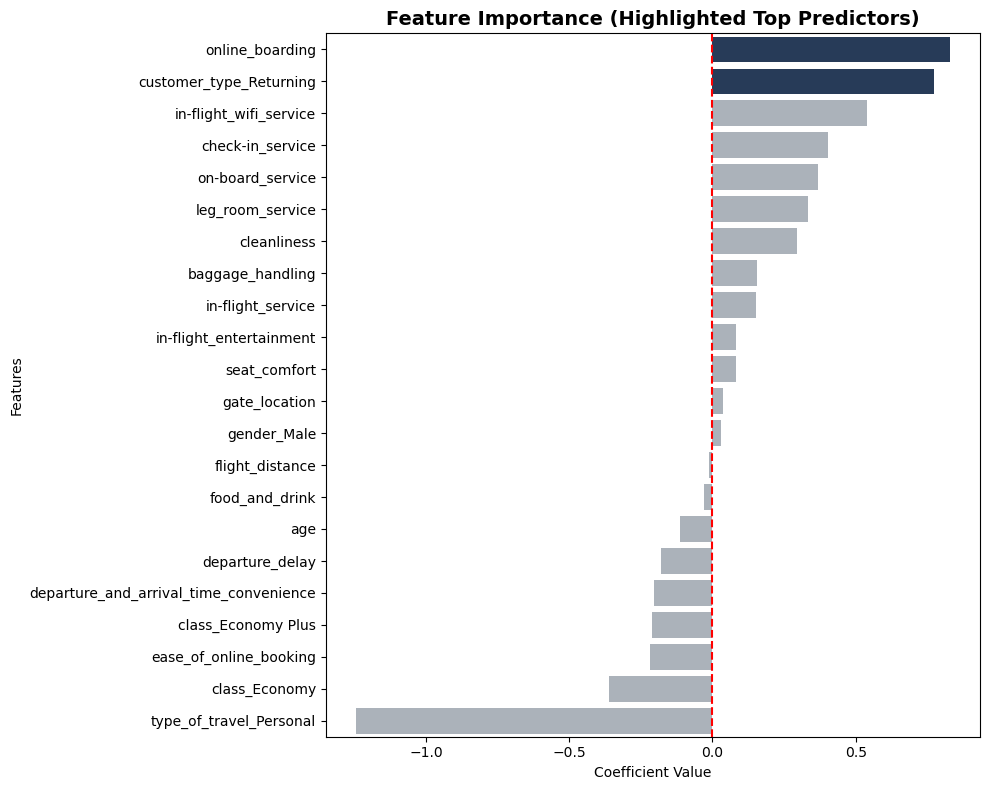

In [179]:
custom_colors = ['#1f3a60' if (x == coef_df['Feature'].iloc[0] or x == coef_df['Feature'].iloc[1]) else '#a8b2bd' for x in coef_df['Feature']]
plt.figure(figsize=(10, 8))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', palette=custom_colors, hue='Feature', legend=False)
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
plt.title('Feature Importance (Highlighted Top Predictors)', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [181]:
# Model 2 Training & Prediction
# Note: you are not required to answer in this single cell, create more cells if needed
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),   
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

knn_train_accuracy = knn_pipeline.score(X_train, y_train)
knn_test_accuracy = knn_pipeline.score(X_test, y_test)

y_pred_knn = knn_pipeline.predict(X_test)

print("--- KNN Performance (K=5) ---")
print(f"Training Accuracy : {knn_train_accuracy:.4f}")
print(f"Testing Accuracy  : {knn_test_accuracy:.4f}")

--- KNN Performance (K=5) ---
Training Accuracy : 0.9508
Testing Accuracy  : 0.9295


In [183]:
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11]
}

grid_search = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

grid_search.fit(X_train, y_train)

best_k = grid_search.best_params_['knn__n_neighbors']
best_score = grid_search.best_score_

print("--- Hyperparameter Tuning ---")
print(f"Best K : {best_k}")
print(f"Best Cross-Validation Accuracy: {best_score:.4f}\n")

best_knn_model = grid_search.best_estimator_
test_acc_best = best_knn_model.score(X_test, y_test)
print(f"Testing Accuracy with Best K: {test_acc_best:.4f}")

--- Hyperparameter Tuning ---
Best K : 5
Best Cross-Validation Accuracy: 0.9287

Testing Accuracy with Best K: 0.9295


## Part 4: Evaluation
* Output the classification reports and confusion matrices for all models.

In [ ]:
# Evaluation metrics
# Note: you are not required to answer in this single cell, create more cells if needed


## Part 5: Final Comparative Analysis
*(Double click this cell to edit)*

**Write your final conclusions here:**
Which model performed best according to your metrics, and why do you think that is?
